In [1]:
# import all the packages; need to pip install any packages that fail import
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read the CSV file using Pandas, and display the top 5 rows prior to any data manipulation
# note that we expect the file to be in the current directory
def get_data(file_name):
    df = pd.read_csv(file_name)
    return df

def restructure_data(df):
    # remove the dummy suffixes from the columns
    df = df.rename(columns=lambda col: col.replace(' dummy', ''))
    
    return transform_data(df)

def transform_data(df):
    # append a new column to the end of the data frame that is based on the highest index value
    # in the zip_convert columns, which are binary values set to 0 or 1
    df['region'] = df.loc[:, 'zipconvert_2':'zipconvert_5'].idxmax(axis=1)

    # replace the zipconvert_ value with blanks using a regular expression
    df = df.replace({'region': 'zipconvert_'}, {'region':''}, regex=True)

    # drop extraneous columns
    df.drop(['Row Id', 'Row Id.', 'zipconvert_2', 'zipconvert_3', 'zipconvert_4', 'zipconvert_5'],  axis=1, inplace=True)
    return df

def check_data(df):
    # check to see if there is any null data
    print('\nChecking for NULL data')
    print(donor_data.isnull().values.any())

In [3]:
file_name = "../data/donors_data.csv"
donor_data = get_data(file_name)

# now what does the dataframe look like?
donor_data.describe()

,Row Id,Row Id.,zipconvert_2,zipconvert_3,zipconvert_4,zipconvert_5,homeowner dummy,NUMCHLD,INCOME,gender dummy,...,IC15,NUMPROM,RAMNTALL,MAXRAMNT,LASTGIFT,totalmonths,TIMELAG,AVGGIFT,TARGET_B,TARGET_D
count,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,...,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.000000,3120.00000,3120.000000
mean,1560.500000,11615.770833,0.214423,0.185256,0.214423,0.384615,0.770192,1.069231,3.893910,0.609295,...,14.702885,49.089423,110.399875,16.651397,13.522917,31.136859,6.861859,10.690713,0.50000,6.499612
std,900.810746,6698.678131,0.410487,0.388568,0.410487,0.486582,0.420777,0.347688,1.636186,0.487987,...,12.079882,22.717130,147.299933,22.223521,10.581439,4.132952,5.561209,7.443980,0.50008,10.597849
min,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,11.000000,15.000000,5.000000,0.000000,17.000000,0.000000,2.138889,0.00000,0.000000
25%,780.750000,5820.750000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000,...,5.000000,29.000000,45.000000,10.000000,7.000000,29.000000,3.000000,6.356092,0.00000,0.000000
50%,1560.500000,11735.500000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4.000000,1.000000,...,12.000000,48.000000,81.000000,15.000000,10.000000,31.000000,5.000000,9.000000,0.50000,0.500000
75%,2340.250000,17435.750000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,...,21.000000,65.000000,134.625000,20.000000,16.000000,34.000000,9.000000,12.811652,1.00000,10.000000
max,3120.000000,23293.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,7.000000,1.000000,...,90.000000,157.000000,5674.900000,1000.000000,219.000000,37.000000,77.000000,122.166667,1.00000,200.000000


In [4]:
donor_data.head()

,Row Id,Row Id.,zipconvert_2,zipconvert_3,zipconvert_4,zipconvert_5,homeowner dummy,NUMCHLD,INCOME,gender dummy,...,IC15,NUMPROM,RAMNTALL,MAXRAMNT,LASTGIFT,totalmonths,TIMELAG,AVGGIFT,TARGET_B,TARGET_D
0,1,17,0,1,0,0,1,1,5,1,...,1,74,102.0,6.0,5.0,29,3,4.857143,1,5.0
1,2,25,1,0,0,0,1,1,1,0,...,4,46,94.0,12.0,12.0,34,6,9.400000,1,10.0
2,3,29,0,0,0,1,0,2,5,1,...,13,32,30.0,10.0,5.0,29,7,4.285714,1,5.0
3,4,38,0,0,0,1,1,1,3,0,...,4,94,177.0,10.0,8.0,30,3,7.080000,0,0.0
4,5,40,0,1,0,0,1,1,4,0,...,7,20,23.0,11.0,11.0,30,6,7.666667,0,0.0


In [5]:
# restructure the data frame, then check it for NAs
donor_data = restructure_data(donor_data)

check_data(donor_data)


Checking for NULL data
False


In [6]:
# now what does the data in the dataframe look like?
donor_data.head()

,homeowner,NUMCHLD,INCOME,gender,WEALTH,HV,Icmed,Icavg,IC15,NUMPROM,RAMNTALL,MAXRAMNT,LASTGIFT,totalmonths,TIMELAG,AVGGIFT,TARGET_B,TARGET_D,region
0,1,1,5,1,9,1399,637,703,1,74,102.0,6.0,5.0,29,3,4.857143,1,5.0,3
1,1,1,1,0,7,698,422,463,4,46,94.0,12.0,12.0,34,6,9.400000,1,10.0,2
2,0,2,5,1,8,828,358,376,13,32,30.0,10.0,5.0,29,7,4.285714,1,5.0,5
3,1,1,3,0,4,1471,484,546,4,94,177.0,10.0,8.0,30,3,7.080000,0,0.0,5
4,1,1,4,0,8,547,386,432,7,20,23.0,11.0,11.0,30,6,7.666667,0,0.0,3


In [7]:
#let's do some comparisons

# what is the average value of lifetime donations by gender?
calc = round(donor_data.groupby(['gender'])["RAMNTALL"].mean(), 2)
print('\nAverage lifetime donations by gender')
print(calc)

# what is the average gift amount by region?
calc = round(donor_data.groupby(['region'])["AVGGIFT"].mean(), 2)
print('\nAverage gift amount by region')
print(calc)

# what is the average gift amount by region and income?
calc = round(donor_data.groupby(['region', 'INCOME'] )["AVGGIFT"].mean(), 2) 
print('\nAverage gift amount by region and median household income')
print(calc)

# what is the average gift amount by income?
calc = round(donor_data.groupby(['INCOME'] )["AVGGIFT"].mean(), 2)
print('\nAverage gift amount by median household income')
print(calc)



Average lifetime donations by gender
gender
0    103.95
1    114.54
Name: RAMNTALL, dtype: float64

Average gift amount by region
region
2    10.59
3     9.73
4    10.30
5    11.43
Name: AVGGIFT, dtype: float64

Average gift amount by region and median household income
region  INCOME
2       1          8.71
        2          9.76
        3         10.29
        4         10.22
        5         11.56
        6         11.30
        7         13.85
3       1          8.43
        2          9.05
        3          9.48
        4          9.14
        5         10.80
        6         11.41
        7         13.52
4       1          9.98
        2          9.73
        3          9.22
        4         10.65
        5          9.65
        6         12.21
        7         11.46
5       1         10.55
        2         10.60
        3         10.20
        4         11.21
        5         11.44
        6         12.71
        7         13.94
Name: AVGGIFT, dtype: float64

Average gif

<Axes: xlabel='INCOME', ylabel='Average gift'>

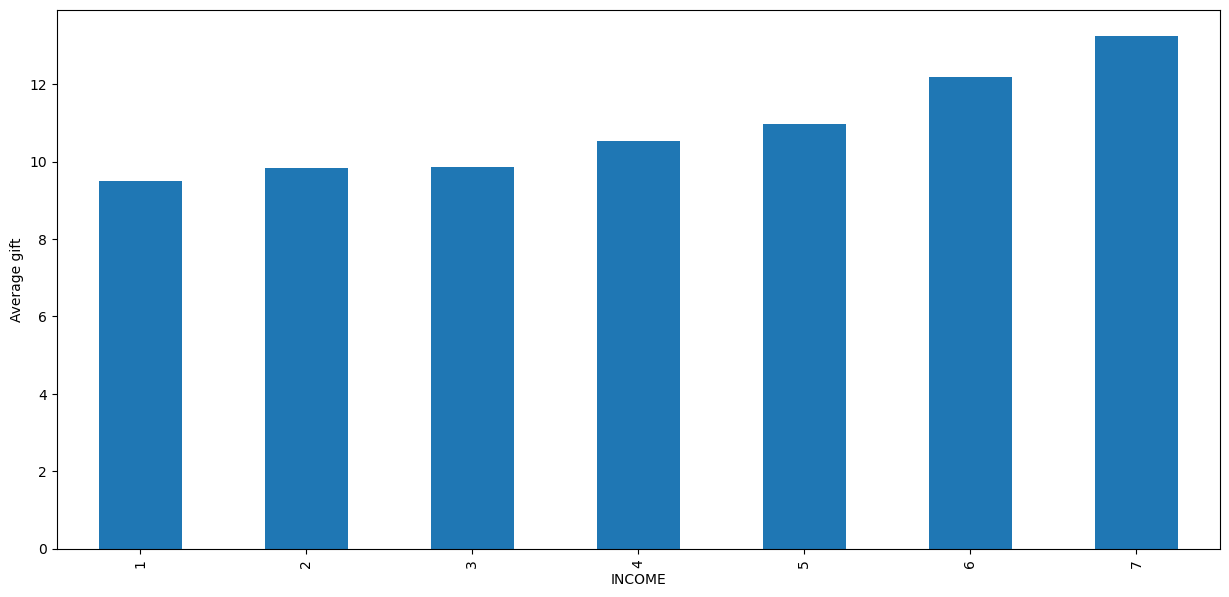

In [8]:
# plot the average donation amount by income
# this is a work in progress
calc = donor_data.groupby(['INCOME'] )['AVGGIFT'].mean()
fig, ax = plt.subplots(figsize=(15,7))
ax.set_xlabel('Income')
ax.set_ylabel('Average gift')

calc.plot(ax = ax, kind='bar')


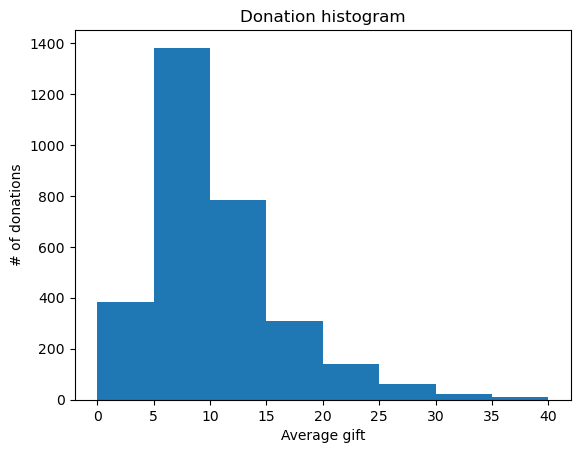

In [9]:
# what is the distribution of average donations (histogram)?
plt.hist(donor_data.AVGGIFT[donor_data.AVGGIFT < 40], bins=[0, 5, 10, 15, 20, 25, 30, 35, 40])
plt.title('Donation histogram')
plt.xlabel('Average gift')
plt.ylabel('# of donations')
plt.show()

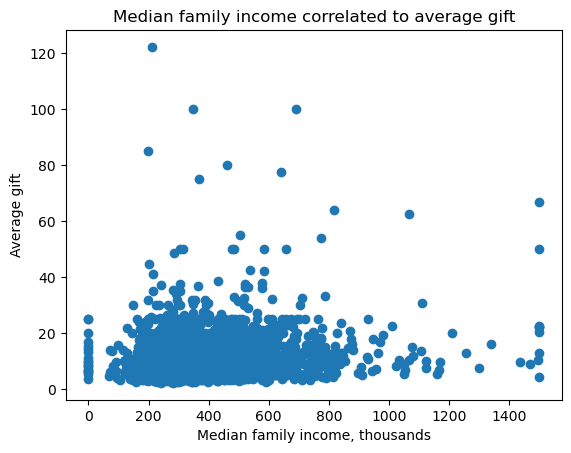

In [10]:
# Is income correlated to average donation?
plt.scatter(donor_data.Icmed, donor_data.AVGGIFT)
plt.title('Median family income correlated to average gift')
plt.xlabel('Median family income, thousands')
plt.ylabel('Average gift')
plt.show()


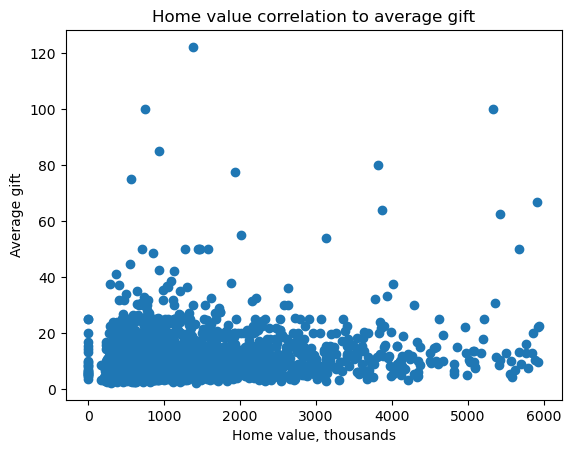

In [11]:
# is home value correlated to average donation?
plt.scatter(donor_data.HV, donor_data.AVGGIFT)
plt.title('Home value correlation to average gift')
plt.xlabel('Home value, thousands')
plt.ylabel('Average gift')
plt.show()

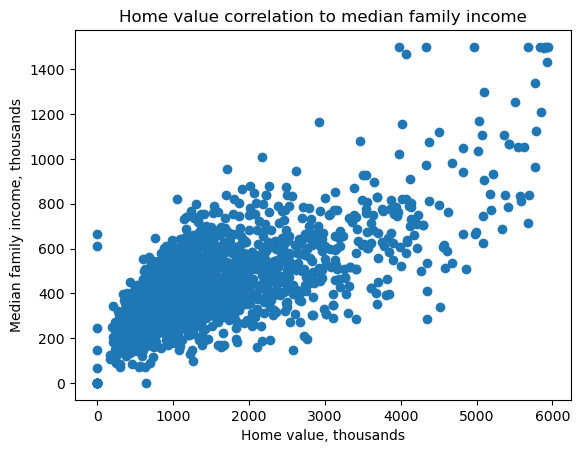

In [12]:
# hmmm nothing seems correlated. Is home value correlated to median income?
plt.scatter(donor_data.HV, donor_data.Icmed)
plt.title('Home value correlation to median family income')
plt.xlabel('Home value, thousands')
plt.ylabel('Median family income, thousands')
plt.show()